# Mini Python Banking Project

In [5]:
# Step 1:  Create banking-related DataFrame and suggest KPIs/metrics for charts
import pandas as pd
import numpy as np

# Create sample banking dataset - FIXED Loan_Amount generation
np.random.seed(42)
n_customers = 1000

# Generate Loan_Amount properly: 70% have 0, 30% have random amounts
has_loan = np.random.choice([True, False], n_customers, p=[0.3, 0.7])
loan_amounts = np.zeros(n_customers)
loan_amounts[has_loan] = np.random.uniform(5000, 50000, sum(has_loan)).round(2)

data = {
    'Customer_ID': range(1, n_customers + 1),
    'Age': np.random.randint(18, 80, n_customers),
    'Account_Type': np.random.choice(['Savings', 'Checking', 'Credit'], n_customers),
    'Balance': np.random.lognormal(10, 2, n_customers).round(2),
    'Transactions': np.random.poisson(50, n_customers),
    'Quarter': np.random.choice(['Q1', 'Q2', 'Q3', 'Q4'], n_customers),
    'Branch': np.random.choice(['Main', 'East', 'West', 'South'], n_customers),
    'Loan_Amount': loan_amounts,
    'Default_Status': np.random.choice([0, 1], n_customers, p=[0.95, 0.05])
}

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

print("\nSuggested KPIs and Metrics for Charts [web:1][web:2][web:16][web:19]:")
print("- Average Balance by Account Type (Bar Chart)")
print("- Balance Trend by Quarter (Line Chart)")
print("- Age vs Balance correlation (Scatter Plot)")
print("- Account Type Distribution (Pie/Donut Chart)")
print("- Transactions vs Balance by Branch (Bar Chart)")
print("- Default Rate by Age Group (Bar Chart)")
print("- Total Loans by Branch (Bar Chart)")
print("- Loan Default Rate by Account Type (Bar Chart)")


Dataset shape: (1000, 9)

First 5 rows:
   Customer_ID  Age Account_Type    Balance  Transactions Quarter Branch  \
0            1   71     Checking    1381.20            57      Q3   West   
1            2   29     Checking  151172.67            50      Q2   West   
2            3   40      Savings    4607.60            41      Q3   West   
3            4   29      Savings    2541.78            53      Q1   East   
4            5   30       Credit  129432.91            48      Q3   Main   

   Loan_Amount  Default_Status  
0         0.00               0  
1         0.00               0  
2         0.00               0  
3         0.00               0  
4     13330.98               0  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     1000 non-null   int64  
 1   Age             1000 non-null   int32  
 2   

In [6]:
# Step 2: Install required additional packages for Jupyter Notebook
# Already provided - run this in a separate cell
!pip install plotly reportlab



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Step 3: Data understanding (run after Step 1)
print("=== DATA UNDERSTANDING REPORT ===")
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")
print(f"\nAccount Type Distribution:\n{df['Account_Type'].value_counts()}")
print(f"\nBalance Summary:\n{df['Balance'].describe()}")
print(f"\nLoan Statistics:\n{df['Loan_Amount'].describe()}")
print(f"\nDefault Rate: {df['Default_Status'].mean()*100:.2f}%")
print(f"\nCustomers with Loans: {sum(df['Loan_Amount'] > 0)} ({sum(df['Loan_Amount'] > 0)/len(df)*100:.1f}%)")


=== DATA UNDERSTANDING REPORT ===
Dataset Shape: (1000, 9)

Columns: ['Customer_ID', 'Age', 'Account_Type', 'Balance', 'Transactions', 'Quarter', 'Branch', 'Loan_Amount', 'Default_Status']

Data Types:
Customer_ID         int64
Age                 int32
Account_Type       object
Balance           float64
Transactions        int32
Quarter            object
Branch             object
Loan_Amount       float64
Default_Status      int64
dtype: object

Missing Values:
Customer_ID       0
Age               0
Account_Type      0
Balance           0
Transactions      0
Quarter           0
Branch            0
Loan_Amount       0
Default_Status    0
dtype: int64

Basic Statistics:
       Customer_ID          Age       Balance  Transactions   Loan_Amount  \
count  1000.000000  1000.000000  1.000000e+03   1000.000000   1000.000000   
mean    500.500000    47.885000  1.746076e+05     49.909000   9044.658670   
std     288.819436    18.000661  7.414922e+05      7.223219  15272.136643   
min       1.0

In [8]:
# Step 4: Data cleaning (run after Step 3)
print("=== DATA CLEANING ===")

df_clean = df[df['Balance'] >= 0].copy()  # Remove negative balances
print(f"Removed {len(df) - len(df_clean)} negative balance records")

# Cap extreme outliers (top 1%)
balance_q99 = df_clean['Balance'].quantile(0.99)
outliers_capped = sum(df_clean['Balance'] > balance_q99)
df_clean.loc[df_clean['Balance'] > balance_q99, 'Balance'] = balance_q99
print(f"Capped {outliers_capped} extreme balances")

# Create Age Groups
def age_group(age):
    if age < 30: return 'Young'
    elif age < 50: return 'Middle'
    else: return 'Senior'

df_clean['Age_Group'] = df_clean['Age'].apply(age_group)

# Remove inactive accounts
inactive = sum(df_clean['Transactions'] == 0)
df_clean = df_clean[df_clean['Transactions'] > 0].copy()
print(f"Removed {inactive} inactive accounts")

print(f"Final clean dataset shape: {df_clean.shape}")
print("Data cleaning complete!")


=== DATA CLEANING ===
Removed 0 negative balance records
Capped 10 extreme balances
Removed 0 inactive accounts
Final clean dataset shape: (1000, 10)
Data cleaning complete!


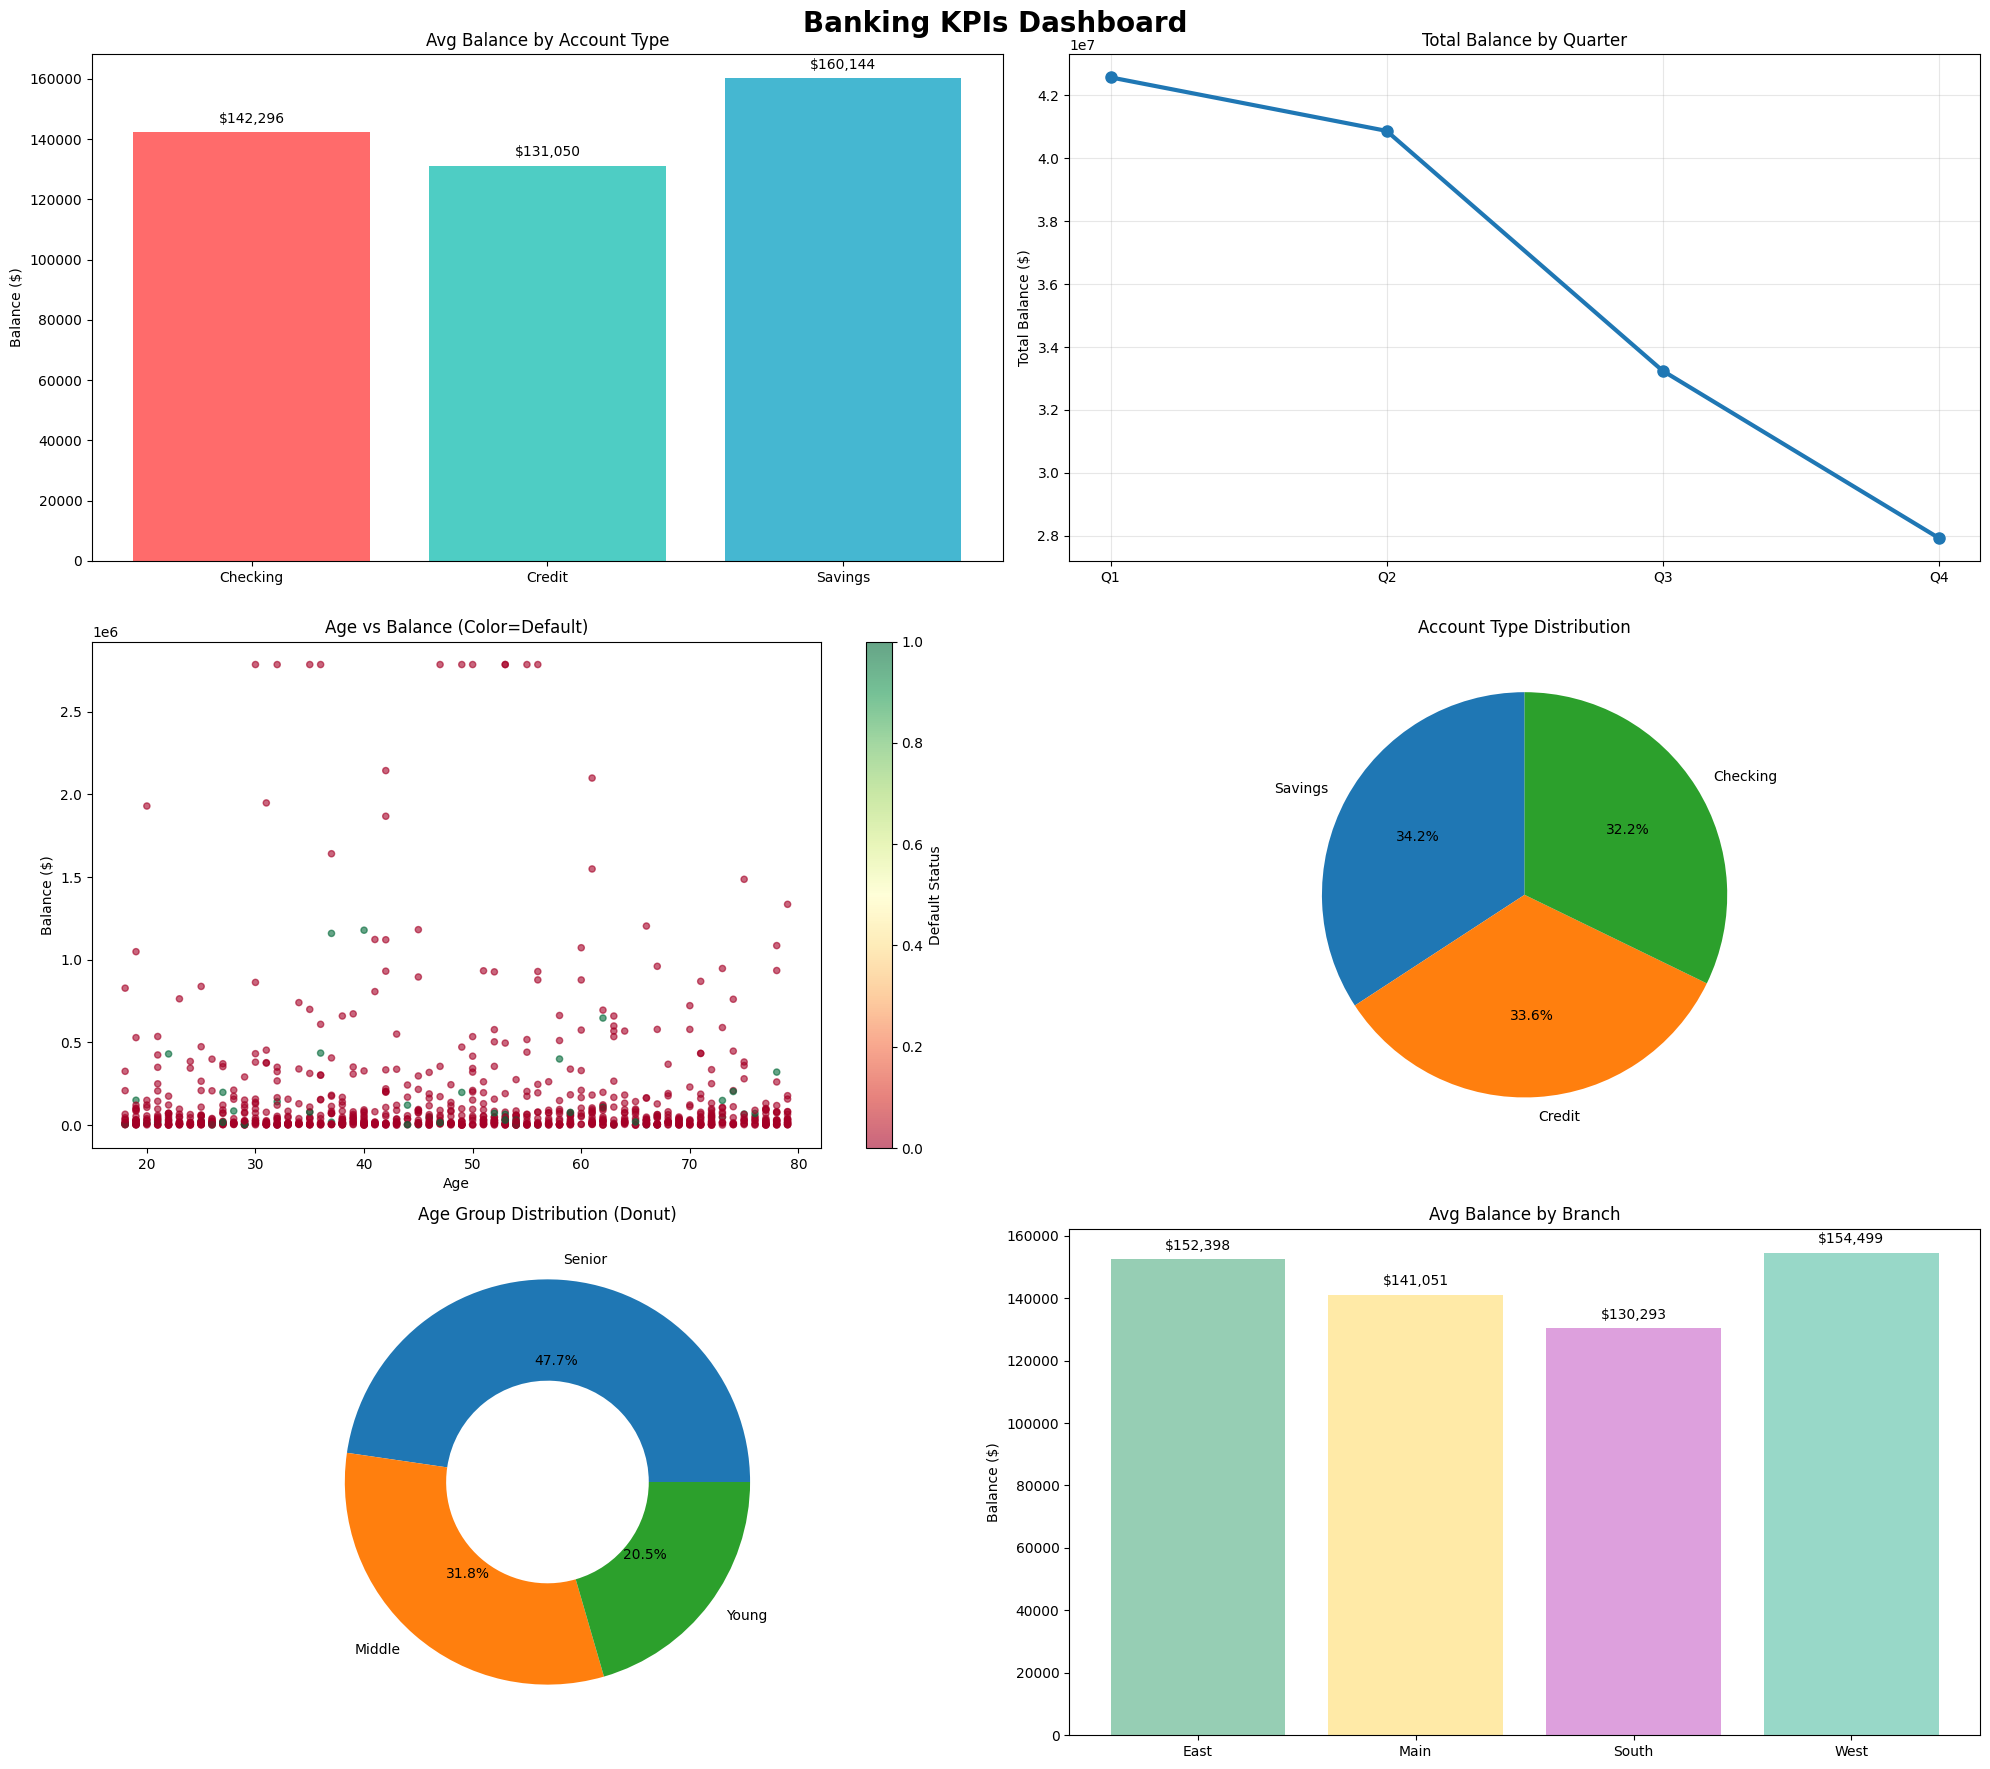

 5 KPI Charts created successfully!


In [9]:
# Step 5: Create 5 KPI charts (run after Step 4)
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Banking KPIs Dashboard', fontsize=20, fontweight='bold')

# 1. Bar Chart: Average Balance by Account Type
avg_balance = df_clean.groupby('Account_Type')['Balance'].mean()
axes[0,0].bar(avg_balance.index, avg_balance.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0,0].set_title('Avg Balance by Account Type')
axes[0,0].set_ylabel('Balance ($)')
for i, v in enumerate(avg_balance.values):
    axes[0,0].text(i, v + max(avg_balance.values)*0.02, f'${v:,.0f}', ha='center')

# 2. Line Chart: Total Balance by Quarter
quarter_balance = df_clean.groupby('Quarter')['Balance'].sum().reindex(['Q1','Q2','Q3','Q4'])
axes[0,1].plot(quarter_balance.index, quarter_balance.values, marker='o', linewidth=3, markersize=8)
axes[0,1].set_title('Total Balance by Quarter')
axes[0,1].set_ylabel('Total Balance ($)')
axes[0,1].grid(True, alpha=0.3)

# 3. Scatter Plot: Age vs Balance
scatter = axes[1,0].scatter(df_clean['Age'], df_clean['Balance'], 
                           c=df_clean['Default_Status'], cmap='RdYlGn', alpha=0.6, s=20)
axes[1,0].set_title('Age vs Balance (Color=Default)')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Balance ($)')
plt.colorbar(scatter, ax=axes[1,0], label='Default Status')

# 4. Pie Chart: Account Type Distribution
account_dist = df_clean['Account_Type'].value_counts()
axes[1,1].pie(account_dist.values, labels=account_dist.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Account Type Distribution')

# 5. Donut Chart: Age Group Distribution
age_dist = df_clean['Age_Group'].value_counts()
wedges, texts, autotexts = axes[2,0].pie(age_dist.values, labels=age_dist.index, 
                                        autopct='%1.1f%%', wedgeprops=dict(width=0.5))
axes[2,0].set_title('Age Group Distribution (Donut)')

# Bonus: Branch Performance
branch_balance = df_clean.groupby('Branch')['Balance'].mean()
axes[2,1].bar(branch_balance.index, branch_balance.values, color=['#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8'])
axes[2,1].set_title('Avg Balance by Branch')
axes[2,1].set_ylabel('Balance ($)')
for i, v in enumerate(branch_balance.values):
    axes[2,1].text(i, v + max(branch_balance.values)*0.02, f'${v:,.0f}', ha='center')

plt.tight_layout()
plt.show()
print(" 5 KPI Charts created successfully!")


In [10]:
# Step 6: Export PDF report (run after Step 5)
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('Banking_KPI_Report.pdf') as pdf:
    # Recreate each chart individually for PDF
    fig1 = plt.figure(figsize=(10, 6))
    avg_balance = df_clean.groupby('Account_Type')['Balance'].mean()
    plt.bar(avg_balance.index, avg_balance.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    plt.title('KPI 1: Average Balance by Account Type')
    plt.ylabel('Balance ($)')
    pdf.savefig(fig1, bbox_inches='tight')
    plt.close(fig1)
    
    fig2 = plt.figure(figsize=(10, 6))
    quarter_balance = df_clean.groupby('Quarter')['Balance'].sum().reindex(['Q1','Q2','Q3','Q4'])
    plt.plot(quarter_balance.index, quarter_balance.values, marker='o', linewidth=3, markersize=10)
    plt.title('KPI 2: Total Balance Trend by Quarter')
    plt.ylabel('Total Balance ($)')
    plt.grid(True, alpha=0.3)
    pdf.savefig(fig2, bbox_inches='tight')
    plt.close(fig2)
    
    print(" PDF Report 'Banking_KPI_Report.pdf' created successfully!")
    print(" Check your Jupyter directory for the PDF file.")


 PDF Report 'Banking_KPI_Report.pdf' created successfully!
 Check your Jupyter directory for the PDF file.
